### **Лабораторная работа по теме ARIMA №1**

Данные в файле  M3_152_0.csv

Данные по годам.

Информация о данных отсутствует.

**Задача:**
Подобрать параметры модели ARIMA,  описать процедуру подбора в комментариях,
построить прогноз на 4 года вперед.

Не обязательно использовать тестовое множество, но тестирование прогноза будет плюсом при выставлении оценки.

In [ ]:
# Импортируем необходимые для работы бибилиотеки
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from pandas import DataFrame

In [ ]:
# Загружаем данные
df = pd.read_csv('M3_152_0.csv', header=None, usecols=[1])
df.head()

,1
0,5717.0
1,6374.0
2,5837.5
3,7318.4
4,4613.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       38 non-null     float64
dtypes: float64(1)
memory usage: 436.0 bytes


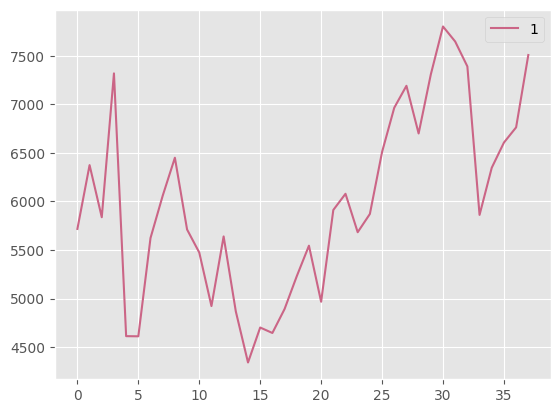

In [ ]:
df.plot(color = '#CB6586')
plt.show()

По графику можно отметить, что ряд скорее всего является нестационарным, с 20 по 30 наблюдения заметен восходящий тренд, а также сильные колебания.

Проверим стационарность ряда с помощью теста Дики-Фуллера.

In [ ]:
result = adfuller(df[1])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
  print('Ряд стационарен')
else:
  print('Ряд нестационарен')

ADF Statistic: -2.237834747907798
p-value: 0.19280121155158764
Ряд нестационарен


Построим графики ACF и PACF для подбора параметров модели ARIMA.

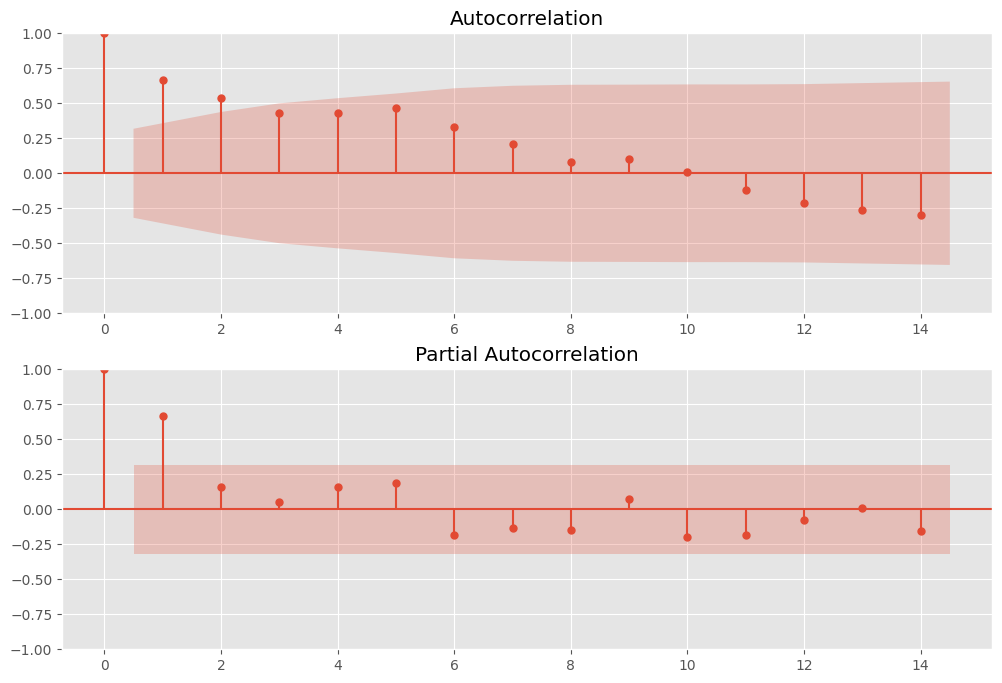

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(df, method='ywmle', lags=14, ax=plt.gca())
plt.show()

По графику видно, что:

*   ACF убывает медленно и не обрывается резко, это является признаком нестационарного ряда -> d = 1
*   PACF показывает значимый пик только на лаге 1, после чего все значения попадают в доверительный интервал -> p = 1
*   Попробуем простые модели: ARIMA(1,1,0), ARIMA(0,1,0), ARIMA(1,1,1).



In [ ]:
# Модель ARIMA(1,1,0)
model_1 = ARIMA(df, order=(1,1,0))
model_fit_1 = model_1.fit()
print(model_fit_1.summary())

                               SARIMAX Results                                
Dep. Variable:                      1   No. Observations:                   38
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -296.555
Date:                Thu, 07 May 2026   AIC                            597.110
Time:                        11:07:28   BIC                            600.332
Sample:                             0   HQIC                           598.246
                                 - 38                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1759      0.157     -1.120      0.263      -0.484       0.132
sigma2      5.173e+05    1.2e+05      4.302      0.000    2.82e+05    7.53e+05
Ljung-Box (L1) (Q):                   0.66   Jarque-

In [ ]:
# Модель ARIMA(0,1,0)
model_2 = ARIMA(df, order=(0,1,0))
model_fit_2 = model_2.fit()
print(model_fit_2.summary())

                               SARIMAX Results                                
Dep. Variable:                      1   No. Observations:                   38
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -297.227
Date:                Thu, 07 May 2026   AIC                            596.455
Time:                        11:12:08   BIC                            598.066
Sample:                             0   HQIC                           597.023
                                 - 38                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.555e+05    8.2e+04      6.776      0.000    3.95e+05    7.16e+05
Ljung-Box (L1) (Q):                   2.92   Jarque-Bera (JB):                28.60
Prob(Q):                              0.09   Pr

In [ ]:
# Модель ARIMA(1,1,1)
model_3 = ARIMA(df, order=(1,1,1))
model_fit_3 = model_3.fit()
print(model_fit_3.summary())

                               SARIMAX Results                                
Dep. Variable:                      1   No. Observations:                   38
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -295.328
Date:                Thu, 07 May 2026   AIC                            596.655
Time:                        11:30:21   BIC                            601.488
Sample:                             0   HQIC                           598.359
                                 - 38                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4928      0.316      1.558      0.119      -0.127       1.112
ma.L1         -0.7843      0.238     -3.302      0.001      -1.250      -0.319
sigma2      4.824e+05   1.19e+05      4.046      0.0

Сравним модели

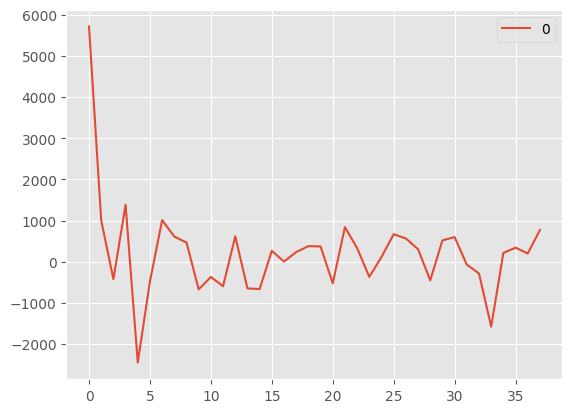

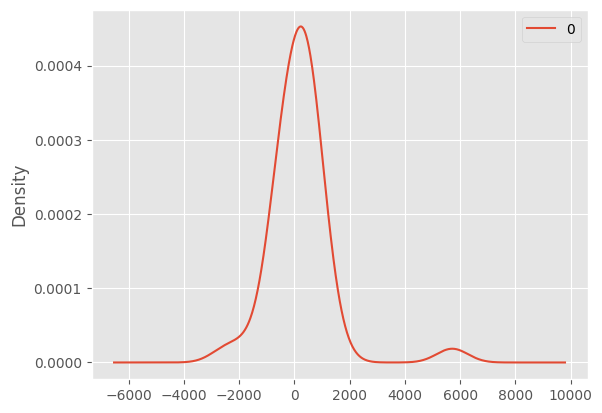

                 0
count    38.000000
mean    211.612609
std    1171.935183
min   -2444.933761
25%    -407.464615
50%     252.103007
75%     592.603680
max    5717.000000


In [ ]:
# Анализ остатков ARIMA(1,1,0)
residuals_1 = pd.DataFrame(model_fit_1.resid)
residuals_1.plot()
plt.show()

residuals_1.plot(kind='kde')
plt.show()
print(residuals_1.describe())

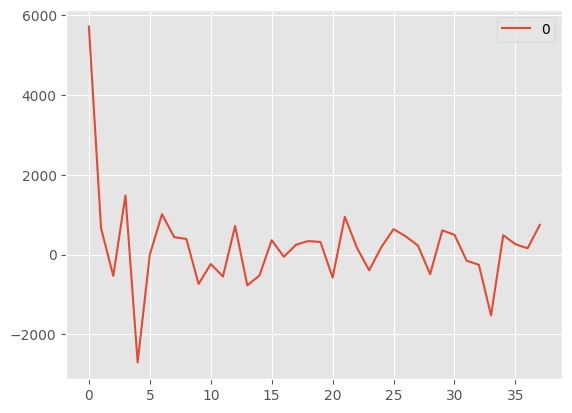

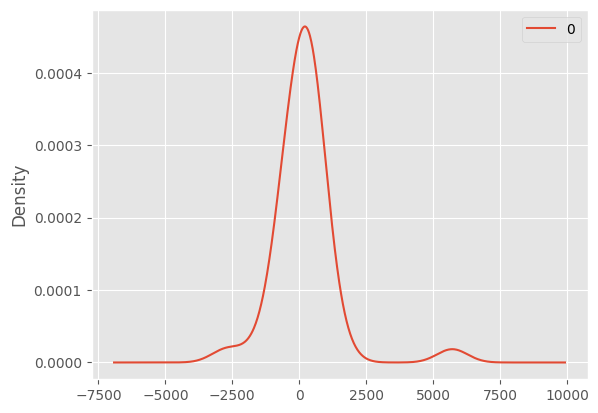

                 0
count    38.000000
mean    197.563158
std    1182.892779
min   -2705.400000
25%    -360.975000
50%     236.300000
75%     491.800000
max    5717.000000


In [ ]:
# Анализ остатков ARIMA(0,1,0)
residuals_2 = pd.DataFrame(model_fit_2.resid)
residuals_2.plot()
plt.show()

residuals_2.plot(kind='kde')
plt.show()
print(residuals_2.describe())

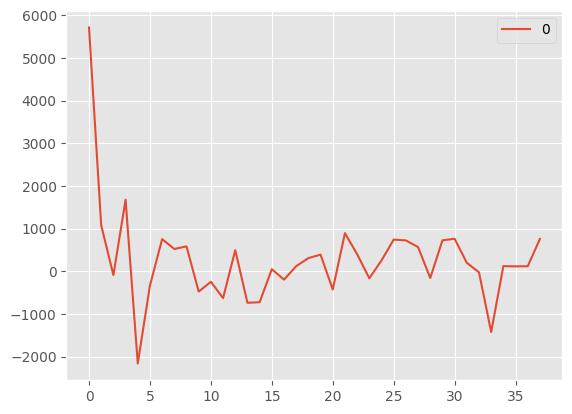

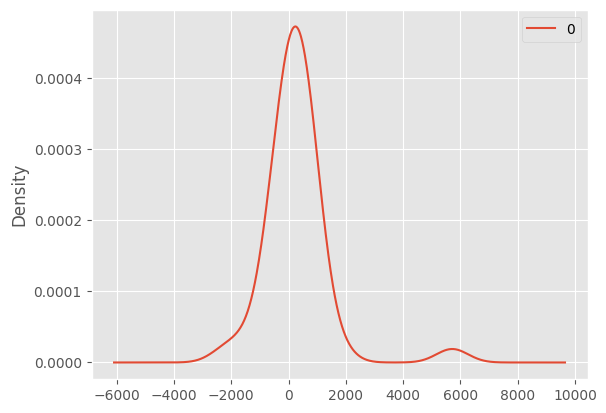

                 0
count    38.000000
mean    274.731274
std    1145.362057
min   -2156.145420
25%    -183.590422
50%     164.251714
75%     692.480597
max    5717.000000


In [ ]:
# Анализ остатков ARIMA(1,1,1)
residuals_3 = pd.DataFrame(model_fit_3.resid)
residuals_3.plot()
plt.show()

residuals_3.plot(kind='kde')
plt.show()
print(residuals_3.describe())

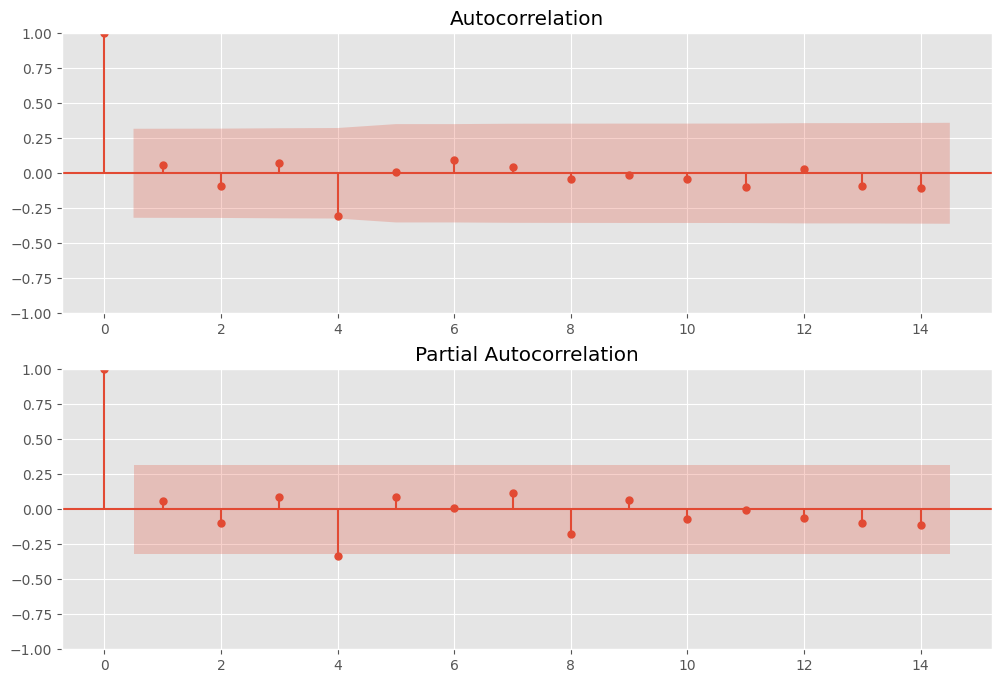

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_1, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_1, method='ywmle', lags=14, ax=plt.gca())
plt.show()

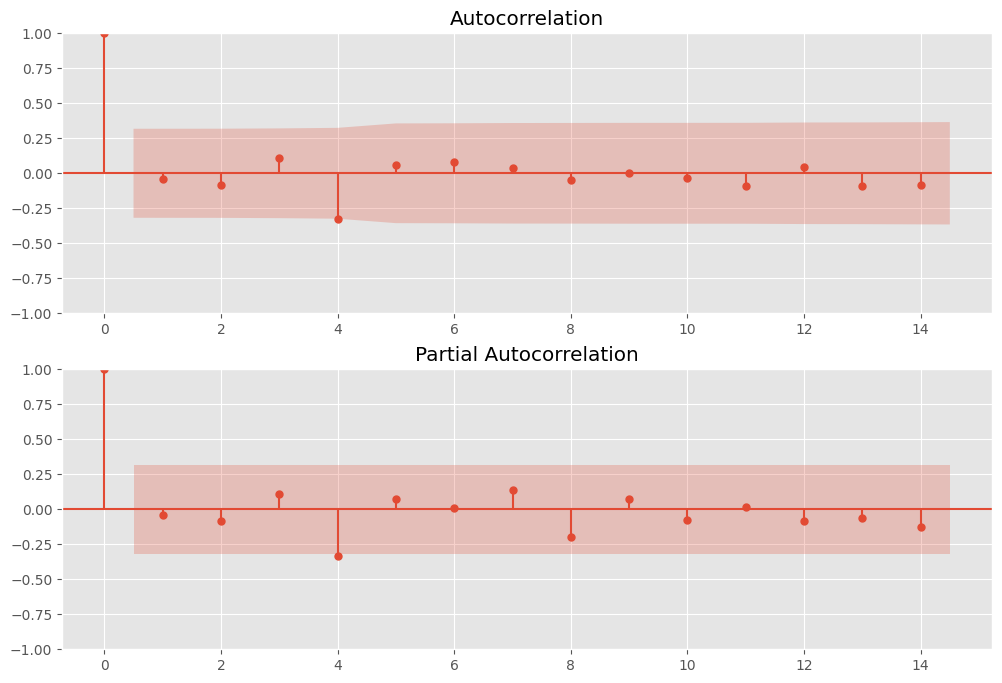

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_2, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_2, method='ywmle', lags=14, ax=plt.gca())
plt.show()

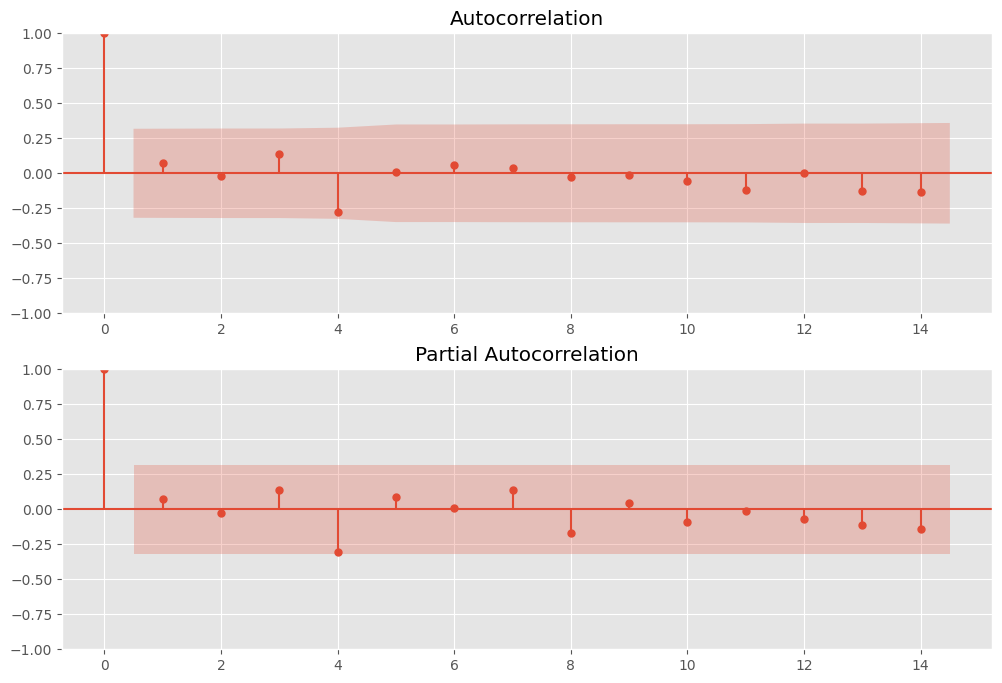

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_3, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_3, method='ywmle', lags=14, ax=plt.gca())
plt.show()

In [ ]:
# Сравнение моделей по AIC и BIC
comparison = pd.DataFrame({
    'Model': ['ARIMA(1,1,0)', 'ARIMA(0,1,0)', 'ARIMA(1,1,1)'],
    'AIC': [model_fit_1.aic, model_fit_2.aic, model_fit_3.aic],
    'BIC': [model_fit_1.bic, model_fit_2.bic, model_fit_3.bic]})

comparison = comparison.sort_values('AIC')
print(comparison)

          Model         AIC         BIC
1  ARIMA(0,1,0)  596.454683  598.065601
2  ARIMA(1,1,1)  596.655218  601.487972
0  ARIMA(1,1,0)  597.110482  600.332318


По результатам сравнения моделей выбираем ARIMA(0,1,0):

- Наименьший BIC (598.066);
- AIC сопоставим с остальными моделями (разница < 1);
- Остатки во всех моделях ведут себя одинаково — ACF/PACF остатков не выявили структуры;
- Коэффициенты в ARIMA(1,1,0) и ARIMA(1,1,1) оказались незначимы.

Модель ARIMA(0,1,0) соответствует процессу случайного блуждания (Random Walk), при котором изменения ряда носят преимущественно случайный характер.

Построим прогноз на 4 года вперед

MAPE = 13.54%


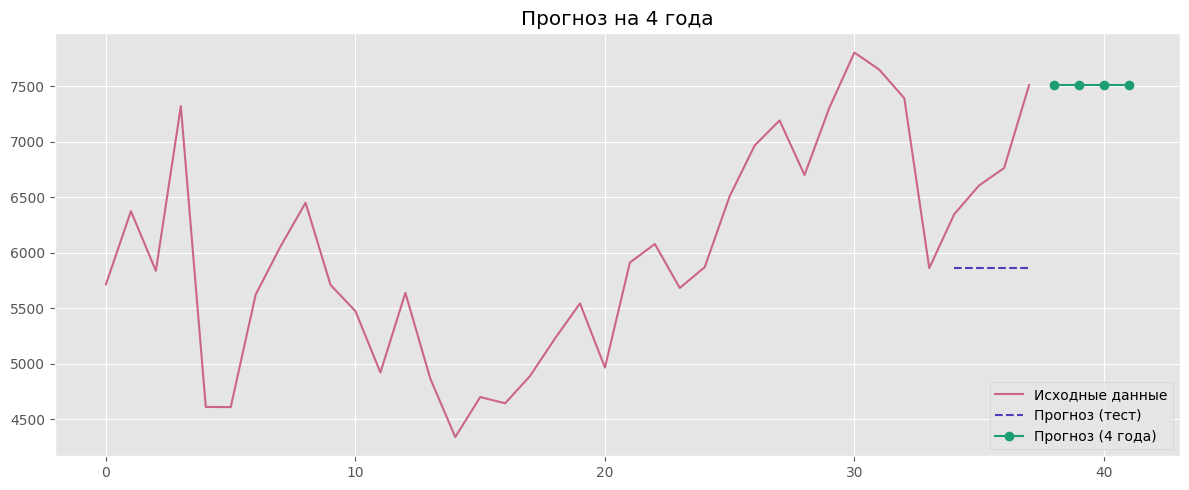

In [ ]:
# Разбивка на train/test (последние 4 наблюдения = тест)
train = df.iloc[:-4]
test = df.iloc[-4:]

# Обучаем модель на train
model_train = ARIMA(train, order=(0,1,0))
model_train_fit = model_train.fit()

# Прогноз на тестовый период
pred = model_train_fit.get_forecast(steps=4)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int(alpha=0.05)

# Метрика качества
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(test, pred_mean)
print(f'MAPE = {mape:.2%}')

# Переобучаем на всех данных → прогноз на 4 года вперёд
final_model = ARIMA(df, order=(0,1,0))
final_fit = final_model.fit()

forecast = final_fit.get_forecast(steps=4)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int(alpha=0.05)

# Визуализация
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df.index, df[1], color='#CB6586', label='Исходные данные')
ax.plot(test.index, pred_mean, '--', color='#533AB7', label='Прогноз (тест)')
ax.plot(range(len(df), len(df)+4), fc_mean, 'o-', color='#1D9E75', label='Прогноз (4 года)')
ax.legend()
plt.title('Прогноз на 4 года')
plt.tight_layout()
plt.show()

По результатам тестирования модели ARIMA(0,1,0) на последних 4 наблюдениях
получили MAPE = 13.54%, что является приемлемым результатом для данного ряда
с высокой вариативностью.

Прогноз на 4 года вперёд остаётся на уровне последнего наблюдения
(~7500) — это ожидаемое поведение модели случайного блуждания, которая в
качестве наилучшей оценки будущего использует последнее известное значение.